# Lasso Regression — Screening the Most Influential ED Wait-Time Predictors

Fits `LassoCV` on the same Model 1 (demographic + access) and Model 2
(+ clinical) feature matrices used in `linear_regression.ipynb`. The L1
penalty shrinks irrelevant one-hot dummy columns to exactly zero, which is
useful here because encoding several categorical families (race, payment
type, arrival mode, month, day of week, ...) produces many sparse columns.
The goal, per `MODELING.md`: use Lasso as a screening step to identify which
patient characteristics, clinical urgency indicators, and demographic
factors carry the most weight in predicting `log_wait_time` — not as a
replacement for the OLS inference in `linear_regression.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

m1 = pd.read_csv("../data/processed/nhamcs_model1_encoded.csv")
m2 = pd.read_csv("../data/processed/nhamcs_model2_encoded.csv")

print(f"Model 1 (demographic + access): {m1.shape[0]:,} rows x {m1.shape[1]} cols")
print(f"Model 2 (+ clinical): {m2.shape[0]:,} rows x {m2.shape[1]} cols")

Model 1 (demographic + access): 329,249 rows x 47 cols
Model 2 (+ clinical): 329,249 rows x 56 cols


Split and scale

Same procedure as `linear_regression.ipynb` (see `MODELING.md` Steps 1-2):
`log_wait_time` is the target, an 80/20 split with `random_state=42`, and
`StandardScaler` fit on the training numeric columns only. Lasso's penalty
is applied uniformly across coefficients, so unscaled numeric features
(`age_years`, `survey_year`, `pulse`, `systolic_bp`) would be penalized
more/less than binary dummies purely because of their scale — scaling
matters more for Lasso than it did for OLS, where it only affected
interpretability.

In [2]:
from sklearn.model_selection import train_test_split

TARGET = "log_wait_time"
DROP = ["wait_time_min", "log_wait_time"]

X1 = m1.drop(columns=DROP)
X2 = m2.drop(columns=DROP)
y = m1[TARGET]  # same rows in both files, so y is identical

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)

print(f"Model 1: X_train {X1_train.shape}, X_test {X1_test.shape}")
print(f"Model 2: X_train {X2_train.shape}, X_test {X2_test.shape}")

Model 1: X_train (263399, 45), X_test (65850, 45)
Model 2: X_train (263399, 54), X_test (65850, 54)


In [3]:
from sklearn.preprocessing import StandardScaler

NUMERIC = ["age_years", "survey_year"]
NUMERIC_M2 = ["age_years", "survey_year", "pulse", "systolic_bp"]

X1_train, X1_test = X1_train.copy(), X1_test.copy()
X2_train, X2_test = X2_train.copy(), X2_test.copy()

scaler1 = StandardScaler()
X1_train[NUMERIC] = scaler1.fit_transform(X1_train[NUMERIC])
X1_test[NUMERIC] = scaler1.transform(X1_test[NUMERIC])

scaler2 = StandardScaler()
X2_train[NUMERIC_M2] = scaler2.fit_transform(X2_train[NUMERIC_M2])
X2_test[NUMERIC_M2] = scaler2.transform(X2_test[NUMERIC_M2])

Fit LassoCV

`LassoCV` selects the regularization strength `alpha` via 5-fold cross-validation
on the training set rather than a manually chosen value.

In [4]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error


def evaluate(model, X_test, y_test, label):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae_log = mean_absolute_error(y_test, preds)
    # Back-transform to minutes for interpretability
    mae_min = mean_absolute_error(np.expm1(y_test), np.expm1(preds))
    print(f"{label}: R2={r2:.4f}  MAE(log)={mae_log:.4f}  MAE(min)={mae_min:.1f}")
    return preds


lasso1 = LassoCV(cv=5, random_state=42, max_iter=5000, n_jobs=-1).fit(X1_train, y_train)
lasso2 = LassoCV(cv=5, random_state=42, max_iter=5000, n_jobs=-1).fit(X2_train, y_train)

_ = evaluate(lasso1, X1_test, y_test, "Lasso — Model 1")
_ = evaluate(lasso2, X2_test, y_test, "Lasso — Model 2")

print(f"\nLasso M1 alpha: {lasso1.alpha_:.5f}")
print(f"Lasso M2 alpha: {lasso2.alpha_:.5f}")

Lasso — Model 1: R2=0.0742  MAE(log)=0.9678  MAE(min)=31.5
Lasso — Model 2: R2=0.0784  MAE(log)=0.9659  MAE(min)=31.4

Lasso M1 alpha: 0.00028
Lasso M2 alpha: 0.00028


**Findings — Lasso vs. OLS performance**

| Model | R² | MAE (log) | MAE (minutes) |
|---|---|---|---|
| Lasso — Model 1 | 0.0742 | 0.9678 | 31.5 |
| Lasso — Model 2 | 0.0784 | 0.9659 | 31.4 |

- Both alphas are selected small (0.00028), which is why performance is nearly
  identical to unpenalized OLS from `linear_regression.ipynb` (R² 0.074 / 0.078,
  MAE 31.5 / 31.4 min) — cross-validation found that only mild regularization
  is needed on this data. Lasso is not sacrificing predictive power to gain
  sparsity here; it's close to a free screening step.
- Model 2 again edges out Model 1 by the same small margin (+0.004 R²) seen
  in the OLS comparison — clinical variables (triage acuity, vitals, prior-visit
  flag) add very little once demographic and access variables are already in
  the model.

Which features does Lasso keep?

Non-zero coefficients are the features Lasso judges informative enough to
keep; zeroed coefficients are the ones it drops entirely. As `MODELING.md`
notes, a zeroed dummy level does not mean the whole categorical family is
unimportant — check zeroed and kept levels of the same family together.

In [5]:
kept1 = pd.Series(lasso1.coef_, index=X1_train.columns)
zeroed1 = kept1[kept1 == 0].index.tolist()
kept1 = kept1[kept1 != 0].sort_values(key=abs, ascending=False)

print(f"Lasso M1 kept {len(kept1)} of {X1_train.shape[1]} features:")
print(kept1.to_string())
print(f"\nLasso M1 zeroed {len(zeroed1)} features: {zeroed1}")

Lasso M1 kept 40 of 45 features:
arrival_mode_Ambulance                       -0.480950
survey_year                                  -0.270390
residence_Homeless                            0.245738
race_Black/African American Only              0.226161
race_More than one race reported              0.176281
residence_Homeless/homeless shelter           0.134119
payment_type_No charge/Charity                0.122018
payment_type_Self-pay                         0.120563
ethnicity_Hispanic or Latino                  0.107197
payment_type_Other                            0.081927
payment_type_Unknown                          0.074673
visit_day_of_week_Saturday                   -0.068697
visit_day_of_week_Monday                      0.067855
visit_month_August                           -0.066884
arrival_mode_Personal transportation          0.064866
payment_type_Medicaid/CHIP                    0.062799
race_American Indian/Alaska Native Only       0.058507
sex_Male                        

**Findings — Model 1 feature selection**

- Lasso drops only 5 of 45 features entirely: `race_Native Hawaiian/Oth Pac Isl Only`,
  `residence_Other institution`, `residence_Other residence`,
  `payment_type_Worker's compensation`, `arrival_mode_Unknown` — all four are
  the smallest categories flagged as low-n in the EDA (n roughly 1,500-3,000),
  consistent with them also being the non-significant coefficients in the OLS
  fit. Lasso is screening out the same weak, imprecisely-estimated groups that
  HC3 standard errors already flagged as non-significant.
- The top of the ranking matches the OLS equity story: `arrival_mode_Ambulance`
  (-0.481) is the single largest effect, followed by `survey_year` (-0.270, the
  downward time trend), then a cluster of demographic/access effects —
  `residence_Homeless` (+0.246), `race_Black/African American Only` (+0.226),
  `race_More than one race reported` (+0.176), `payment_type_No charge/Charity`
  (+0.122), `payment_type_Self-pay` (+0.121), `ethnicity_Hispanic or Latino`
  (+0.107).
- Month and day-of-week dummies survive but with small coefficients
  (|coef| < 0.07) — Lasso keeps them rather than zeroing them, but they rank
  far below the demographic/access/arrival-mode effects.

In [6]:
kept2 = pd.Series(lasso2.coef_, index=X2_train.columns)
zeroed2 = kept2[kept2 == 0].index.tolist()
kept2 = kept2[kept2 != 0].sort_values(key=abs, ascending=False)

print(f"Lasso M2 kept {len(kept2)} of {X2_train.shape[1]} features:")
print(kept2.to_string())
print(f"\nLasso M2 zeroed {len(zeroed2)} features: {zeroed2}")

Lasso M2 kept 50 of 54 features:
arrival_mode_Ambulance                       -0.458222
survey_year                                  -0.270250
residence_Homeless                            0.233575
triage_acuity_High                           -0.230106
race_Black/African American Only              0.228612
race_More than one race reported              0.168006
residence_Homeless/homeless shelter           0.135970
payment_type_No charge/Charity                0.128773
payment_type_Self-pay                         0.117693
seen_72h_Unknown                             -0.116359
ethnicity_Hispanic or Latino                  0.106636
payment_type_Unknown                          0.083047
payment_type_Other                            0.080285
arrival_mode_Personal transportation          0.074298
visit_day_of_week_Saturday                   -0.068892
visit_month_August                           -0.068220
visit_day_of_week_Monday                      0.067897
payment_type_Medicaid/CHIP      

**Findings — Model 2 feature selection**

- Adding clinical variables drops the zeroed-feature count to 4 (from 5 in
  Model 1): `residence_Other institution`, `residence_Other residence`,
  `residence_Unknown`, `payment_type_Worker's compensation`. Notably,
  `race_Native Hawaiian/Oth Pac Isl Only` and `arrival_mode_Unknown` — zeroed
  in Model 1 — come back in with small coefficients once clinical controls
  are added, and `residence_Unknown` is newly zeroed. These are small swaps
  among already-weak features, not a change to the main findings.
- **Every clinical variable Lasso is offered gets kept**, and several rank
  in the top 10 by magnitude: `triage_acuity_High` (-0.230, the 4th-largest
  effect overall), `seen_72h_Unknown` (-0.116), `triage_acuity_Unknown`
  (-0.058), `triage_acuity_Low` (-0.056), `systolic_bp_missing` (-0.056),
  `pulse_missing` (-0.038), `systolic_bp` (-0.029), `pulse` (-0.014),
  `seen_72h_Yes` (+0.010). Lasso confirms clinical urgency signals are
  genuinely informative predictors — it just doesn't rank them above the
  demographic/access effects.
- The demographic and payment coefficients barely move once clinical
  controls are added (e.g. `race_Black/African American Only` +0.226 → +0.229,
  `payment_type_Self-pay` +0.121 → +0.118) — the same "clinical need does not
  explain away the disparity" pattern found in the OLS comparison, now
  confirmed by an independent variable-selection method rather than just a
  coefficient-shrinkage comparison.

Visualize the most influential predictors

Top 20 Model 2 coefficients by magnitude, colored by direction — rose for
"longer wait", blue for "shorter wait" — so the sign is visible without
reading each label.

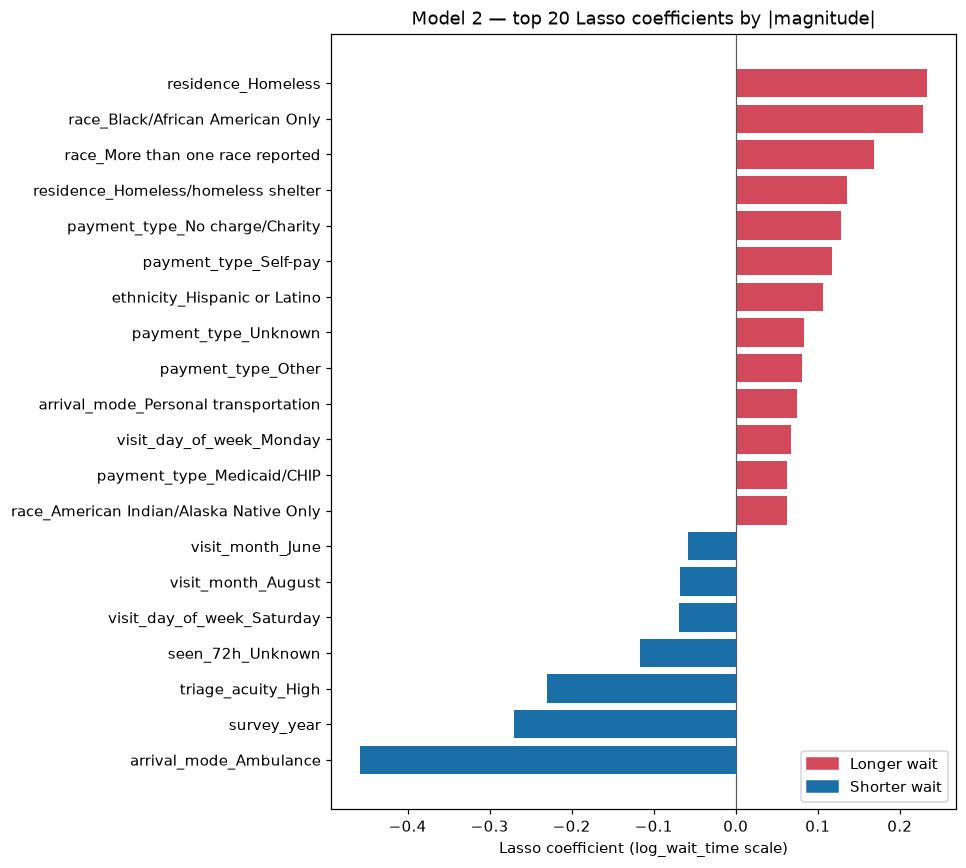

In [7]:
top20 = kept2.head(20).sort_values()
colors = ["#D1495B" if v > 0 else "#1B6FA8" for v in top20.values]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20.index, top20.values, color=colors)
ax.axvline(0, color="#5b5b57", linewidth=0.8)
ax.set_xlabel("Lasso coefficient (log_wait_time scale)")
ax.set_title("Model 2 — top 20 Lasso coefficients by |magnitude|")

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color="#D1495B", label="Longer wait"),
        Patch(color="#1B6FA8", label="Shorter wait"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

Grouping the survivors by category

Mapping the Model 2 kept features (excluding month/day-of-week seasonality
controls, which are not part of the research question) into the three
groups the research question asks about.

In [8]:
CLINICAL = [
    "triage_acuity_High", "triage_acuity_Low", "triage_acuity_Unknown",
    "seen_72h_Unknown", "seen_72h_Yes", "pulse", "systolic_bp",
    "pulse_missing", "systolic_bp_missing",
]
DEMOGRAPHIC = [c for c in kept2.index if c.startswith(("race_", "ethnicity_", "sex_"))]
ACCESS = [c for c in kept2.index if c.startswith(("payment_type_", "arrival_mode_", "residence_"))]
PATIENT_CHAR = ["age_years"] + DEMOGRAPHIC

groups = {
    "Clinical urgency indicators": CLINICAL,
    "Demographic factors": DEMOGRAPHIC,
    "Access / patient-characteristic factors": ["age_years"] + ACCESS,
}

for label, cols in groups.items():
    present = kept2[kept2.index.intersection(cols)].sort_values(key=abs, ascending=False)
    print(f"\n=== {label} ({len(present)} kept) ===")
    print(present.to_string())


=== Clinical urgency indicators (9 kept) ===
triage_acuity_High      -0.230106
seen_72h_Unknown        -0.116359
triage_acuity_Unknown   -0.057547
triage_acuity_Low       -0.056293
systolic_bp_missing     -0.055508
pulse_missing           -0.037809
systolic_bp             -0.029287
pulse                   -0.013713
seen_72h_Yes             0.009505

=== Demographic factors (8 kept) ===
race_Black/African American Only           0.228612
race_More than one race reported           0.168006
ethnicity_Hispanic or Latino               0.106636
race_American Indian/Alaska Native Only    0.062233
sex_Male                                  -0.048920
race_Unknown                               0.019104
race_Asian Only                            0.006303
race_Native Hawaiian/Oth Pac Isl Only     -0.003381

=== Access / patient-characteristic factors (15 kept) ===
arrival_mode_Ambulance                       -0.458222
residence_Homeless                            0.233575
residence_Homeless/homele

**Findings — the most influential predictor in each category**

- **Clinical urgency indicators:** `triage_acuity_High` (-0.230) is by far the
  strongest clinical predictor — high-acuity patients wait meaningfully less.
  The rest of the clinical block (`seen_72h_Unknown`, vitals-missing flags,
  `pulse`/`systolic_bp` themselves) contributes real but much smaller effects
  (|coef| < 0.12).
- **Demographic factors:** `race_Black/African American Only` (+0.229) is the
  most influential demographic predictor, followed by `race_More than one race
  reported` (+0.168) and `ethnicity_Hispanic or Latino` (+0.107). `sex_Male`
  (-0.049) is comparatively minor.
- **Access / patient-characteristic factors:** `arrival_mode_Ambulance`
  (-0.458) dominates this group and the entire model — arriving by ambulance
  is the single strongest predictor of a shorter wait of any feature Lasso
  was given. `residence_Homeless` (+0.234), `payment_type_No charge/Charity`
  (+0.129), and `payment_type_Self-pay` (+0.118) are the next-largest access
  barriers.
- Putting the three groups side by side: **access and demographic factors
  dominate the top of the ranking; clinical urgency (`triage_acuity_High`)
  is the 4th-largest effect in the whole model, not the 1st.** This is the
  same conclusion `linear_regression.ipynb` reached via OLS — Lasso's
  independent variable-selection procedure keeps every clinical signal it
  was offered, but ranks demographic and access barriers as more influential
  predictors of `log_wait_time` than clinical urgency.

## Summary

1. LassoCV selects a small `alpha` (0.00028) for both models — performance
   (R² 0.074-0.078, MAE ~31.5 min) is essentially identical to the unpenalized
   OLS fit in `linear_regression.ipynb`, so sparsity is gained at no real cost
   in fit.
2. Lasso zeroes out only the smallest, already non-significant categories
   (rare race/residence/payment/arrival-mode levels with n roughly 1,500-3,000) —
   it agrees with the OLS significance testing about which features are weak.
3. **Every clinical variable offered to Model 2 survives selection** —
   `triage_acuity_High` is the 4th-most-influential predictor overall — so
   clinical urgency is a real, non-trivial signal, just not the dominant one.
4. **The most influential predictors overall are access and demographic, not
   clinical:** `arrival_mode_Ambulance`, `survey_year`, `residence_Homeless`,
   `race_Black/African American Only`, and payment-type barriers all outrank
   `triage_acuity_High` in magnitude. This corroborates, via an independent
   variable-selection method, the central equity finding from the OLS
   coefficient-shrinkage analysis: documented clinical need does not explain
   away demographic and access-related wait-time disparities.
5. Per `MODELING.md`, Lasso here is a screening step — the coefficient
   magnitudes and signs are directionally trustworthy, but statistical
   significance and confidence intervals should still be read from the
   HC3-robust OLS output in `linear_regression.ipynb`.